## CS310 Natural Language Processing
## Assignment 2. Word2vec Implementation 

**Total points**: 30

Train a word2vec model using the **skip-gram** architecture and **negative sampling**.

You should roughtly follow the structure of the notebook. Add additional cells if you feel needed. 

You can (and you should) re-use the code from *Lab 3: Data preparation for implementing word2vec*. 

Make sure your code is readable and well-structured.

## 0. Import Necessary Libraries

In [1]:
from typing import List
from utils import CorpusReader
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

## 1. Data Processing

The corpus data is in `shakespeare.txt`. Use the `CorpusReader` class in `utils.py` to help you.

In [2]:
### YOUR CODE HERE ###
#初始化CorpusReader
corpus = CorpusReader('shakespeare.txt', min_count=3, lang='en')
print(f"词表大小: {corpus.vocab_size}")

#要一个包含所有分词后的列表方便generate_data函数调用
all_words = []
with open('shakespeare.txt', 'r', encoding='utf-8') as f:
    for line in f:
        import re
        words = re.findall(r"[a-zA-Z0-9]+", line)
        if words:
            all_words.extend(words)
### END YOUR CODE ###

Total vocabulary: 5328
词表大小: 5328
词表大小: 5328


In [3]:
# Re-use the code from lab with necessary modifications

def generate_data(words: List[str], window_size: int, k: int, corpus: CorpusReader):
    """ Generate the training data for word2vec skip-gram model
    Args:
        text: the input text
        window_size: the size of the context window
        k: the number of negative samples
        corpus: the corpus object, providing utilities such as word2id, getNegatives, etc.
    """
    ### YOUR CODE HERE ###
    data = []
    #将单词序列转换为 ID 序列，如果在词表中（min_count过滤后的）则保留
    word_ids = [corpus.word2id[w] for w in words if w in corpus.word2id]
    
    for i in range(len(word_ids)):
        center_id = word_ids[i]
        
        #确定窗口左右边界 不要越界
        start = max(0, i - window_size)
        end = min(len(word_ids), i + window_size + 1)
        
        for j in range(start, end):
            if i == j: continue #跳过自己
            
            outside_id = word_ids[j]
            #获取k个负样本ID
            negative_ids = corpus.getNegatives(outside_id, k)
            
            data.append((center_id, outside_id, negative_ids))
            
    return data
    ### END YOUR CODE ###

def batchify(data: List, batch_size: int):
    """ Group a stream into batches and yield them as torch tensors.
    Args:
        data: a list of tuples
        batch_size: the batch size 
    Yields:
        a tuple of three torch tensors: center, outside, negative
    """
    assert batch_size < len(data) # data should be long enough
    for i in range(0, len(data), batch_size):
        batch = data[i:i + batch_size]
        if len(batch) < batch_size: # if the last batch is smaller than batch_size, pad it with the first few data
            batch = batch + data[:batch_size - len(batch)]
        
        ### YOUR CODE HERE ###
        # 将目前的tuple list解包转为longtensor
        #centers: (batch_size, )
        centers = torch.LongTensor([item[0] for item in batch])
        #outsides: (batch_size, )
        outsides = torch.LongTensor([item[1] for item in batch])
        #negatives: (batch_size, k)
        negatives = torch.LongTensor([item[2] for item in batch])
        
        yield centers, outsides, negatives
        ### END YOUR CODE ###

## 2. Define the Model

In [4]:
class SkipGram(nn.Module):
    def __init__(self, vocab_size, emb_size):
        super(SkipGram, self).__init__()
        self.vocab_size = vocab_size
        self.emb_size = emb_size
        self.emb_v = nn.Embedding(vocab_size, emb_size)
        self.emb_u = nn.Embedding(vocab_size, emb_size)

        initrange = 1.0 / self.emb_size # some experience passed down from generation to generation
        nn.init.uniform_(self.emb_v.weight.data, -initrange, initrange) # same outcome as self.emb_v.weight.data.uniform_(-initrange, initrange)
        nn.init.constant_(self.emb_u.weight.data, 0) # same outcome as self.emb_u.weight.data.zero_()

    def forward(self, center, outside, negative):
        """
        Args:
            center: the center word indices (B, )
            outside: the outside word indices (B, )
            negative: the negative word indices (B, k)
        """
        v_c = self.emb_v(center)
        u_o = self.emb_u(outside)
        u_n = self.emb_u(negative)
        
        ### YOUR CODE HERE ###
        #计算正样本评分：
        loss = None
        pos_score = torch.sum(v_c * u_o, dim=1)  # (B, )
        #计算负样本评分
        neg_scores = torch.bmm(u_n, v_c.unsqueeze(2)).squeeze(2) # (B, k)
        #计算对数sigmoid损失
        #正样本损失: log(sigma(v_c · u_o))
        pos_loss = F.logsigmoid(torch.clamp(pos_score, min=-10, max=10))
        #负样本损失: sum(log(sigma(-v_c · u_n)))
        neg_loss = torch.sum(F.logsigmoid(torch.clamp(-neg_scores, min=-10, max=10)), dim=1) # (B, )
        #合并损失取平均值
        loss = -torch.mean(pos_loss + neg_loss)
        # Hint: torch.clamp the input to F.logsigmoid to avoid numerical underflow/overflow
        ### END YOUR CODE ###

        return loss
    
    def save_embedding(self, id2word, file_name):
        embedding = self.emb_v.weight.cpu().data.numpy()
        with open(file_name, 'w') as f:
            f.write('%d %d\n' % (len(id2word), self.emb_size))
            for wid, w in id2word.items():
                e = ' '.join(map(lambda x: str(x), embedding[wid]))
                f.write('%s %s\n' % (w, e))

## 3. Train and Evaluate

Total vocabulary: 5328


/tmp/ipykernel_4056/2697140145.py:56: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  negatives = torch.LongTensor([item[2] for item in batch])


Epoch [1/50], Step [1000], Loss: 2.6325
Epoch [1/50], Step [2000], Loss: 2.3306
Epoch [1/50], Step [2000], Loss: 2.3306
Epoch [1/50] 完成，平均 Loss: 2.7864
Epoch [1/50] 完成，平均 Loss: 2.7864
Epoch [2/50], Step [1000], Loss: 2.4147
Epoch [2/50], Step [1000], Loss: 2.4147
Epoch [2/50], Step [2000], Loss: 2.2225
Epoch [2/50], Step [2000], Loss: 2.2225
Epoch [2/50] 完成，平均 Loss: 2.5662
Epoch [2/50] 完成，平均 Loss: 2.5662
Epoch [3/50], Step [1000], Loss: 2.3325
Epoch [3/50], Step [1000], Loss: 2.3325
Epoch [3/50], Step [2000], Loss: 2.1705
Epoch [3/50], Step [2000], Loss: 2.1705
Epoch [3/50] 完成，平均 Loss: 2.4488
Epoch [3/50] 完成，平均 Loss: 2.4488
Epoch [4/50], Step [1000], Loss: 2.2407
Epoch [4/50], Step [1000], Loss: 2.2407
Epoch [4/50], Step [2000], Loss: 2.1800
Epoch [4/50], Step [2000], Loss: 2.1800
Epoch [4/50] 完成，平均 Loss: 2.3677
Epoch [4/50] 完成，平均 Loss: 2.3677
Epoch [5/50], Step [1000], Loss: 2.2309
Epoch [5/50], Step [1000], Loss: 2.2309
Epoch [5/50], Step [2000], Loss: 2.1408
Epoch [5/50], Step [2000

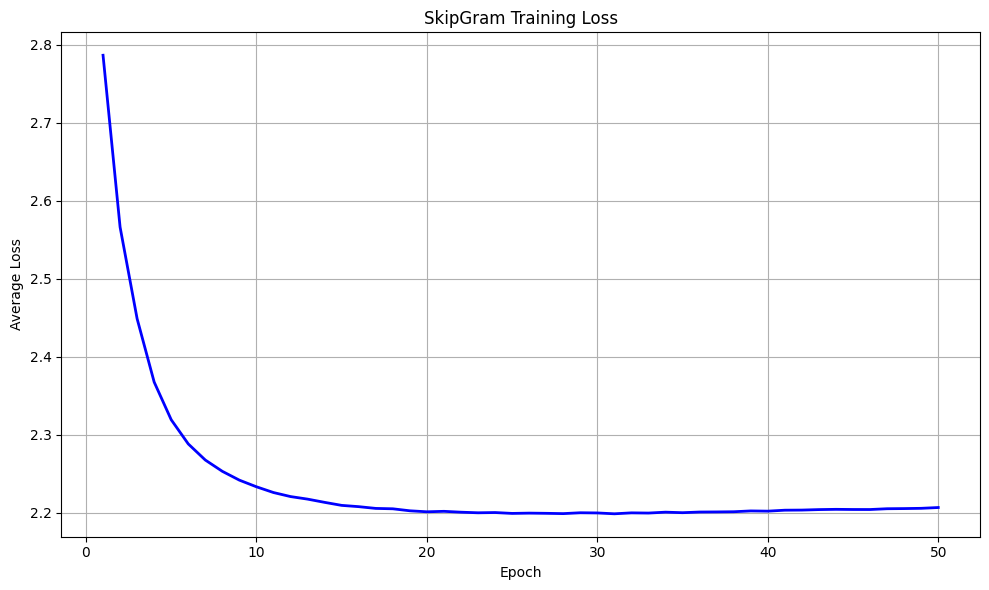

In [5]:
def train(model, dataloader, optimizer, epochs):
    # Write your own code for this train function
    # You don't need exactly the same arguments

    ### YOUR CODE HERE ###
    #保存 loss 历史以便绘图
    loss_history = []
    
    #获取运行设备
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.train() #设置为训练模式
    
    # 将 generator 转换为 list（在 epoch 循环外部），以便每个 epoch 都能重新遍历
    batches = list(dataloader)
    
    for epoch in range(epochs):
        total_loss = 0
        for i, (center, outside, negative) in enumerate(batches):
            # 将张量搬移到 GPU/CPU
            center, outside, negative = center.to(device), outside.to(device), negative.to(device)
            optimizer.zero_grad()    #梯度归零
            loss = model(center, outside, negative) #前向传播
            loss.backward()          # 反向传播
            
            # 修复bug稀疏嵌入不支持clip_grad_norm_，跳过梯度裁剪
            # torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            
            optimizer.step()#更新参数
            
            total_loss += loss.item()
            
            if (i + 1) % 1000 == 0:
                print(f"Epoch [{epoch+1}/{epochs}], Step [{i+1}], Loss: {loss.item():.4f}")
        
        avg_loss = total_loss / (i + 1)
        loss_history.append(avg_loss)
        print(f"Epoch [{epoch+1}/{epochs}] 完成，平均 Loss: {avg_loss:.4f}")
    
    return loss_history

    ### END YOUR CODE ###


# Suggested hyperparameters
initial_lr = 0.01  # 降低学习率，Adam 通常用 0.001-0.01
batch_size = 512
emb_size = 100
window_size = 3
k = 5 # the number of negative samples
min_count = 3 # because our data is small. If min_count > 1, you should filter out those unknown words 
epochs = 50

# Initialize the corpus and model first
corpus = CorpusReader('shakespeare.txt', min_count, lang='en')
vocab_size = corpus.vocab_size
model = SkipGram(vocab_size, emb_size)

# Create optimizer after model is defined
# Note: Using Adam instead of SparseAdam to ensure gradients are properly updated for sparse embeddings
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)

# Generate training data
all_words = []
with open('shakespeare.txt', 'r', encoding='utf-8') as f:
    for line in f:
        import re
        words = re.findall(r"[a-zA-Z0-9]+", line)
        if words:
            all_words.extend(words)

data = generate_data(all_words, window_size, k, corpus)
dataloader = batchify(data, batch_size)

# Train the model
loss_history = train(model, dataloader, optimizer, epochs)

# Plot loss curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(loss_history) + 1), loss_history, 'b-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('SkipGram Training Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

### Hints: ###
# - If you have cuda-supported GPUs, you can run the training faster by
#   `device = torch.device("cuda" if self.use_cuda else "cpu")`
#   `model.cuda()`
#   You also need to move all tensor data to the same device
# - If you find Inf or NaN in the loss, you can try to clip the gradient usning `torch.nn.utils.clip_grad_norm_`
# - Remember to save the embeddings when training is done



## 4. Save the Embeddings


Save the embeddings into a `gensim` compatible format.

In [6]:
output_file = 'embeddings.txt'
model.save_embedding(corpus.id2word, output_file) 

## 5. Plot and Compare Embeddings

Use `sklearn.decomposition.TruncatedSVD` to reduce the dimensionality of the obtained embeddings to 2 and plot the selected words in 2D space.

*Hint*:
- Obtain the embeddings into a numpy array by `model.emb_v.cpu().data.numpy()`
- The word2id dictionary is in `model.word2id`
- If you are trying to load from a saved embedding file, you can use the APIs from `gensim`.
  - For exmaple, `model = gensim.models.KeyedVectors.load_word2vec_format('path/to/file')`
  - Check out the documentation for more details: https://radimrehurek.com/gensim/models/keyedvectors.html

In [7]:
# Load embeddings
### YOUR CODE HERE ###
#从模型的 emb_v 层提取参数并转为 numpy 数组
all_embeddings = model.emb_v.weight.detach().cpu().numpy()
#获取 word 到 id 的映射
word2id = corpus.word2id
### END YOUR CODE ###

In [8]:
# Truncated SVD 降维处理
### YOUR CODE HERE ###
#获取 word 到 id 的映射
#初始化 SVD 模型 n_components制定维度
svd = TruncatedSVD(n_components=2)
#对全量词向量进行拟合与转换
#(vocab_size, 2)
embeddings_2d = svd.fit_transform(all_embeddings)
print(f"降维后的数据形状: {embeddings_2d.shape}")
### END YOUR CODE ###

降维后的数据形状: (5328, 2)


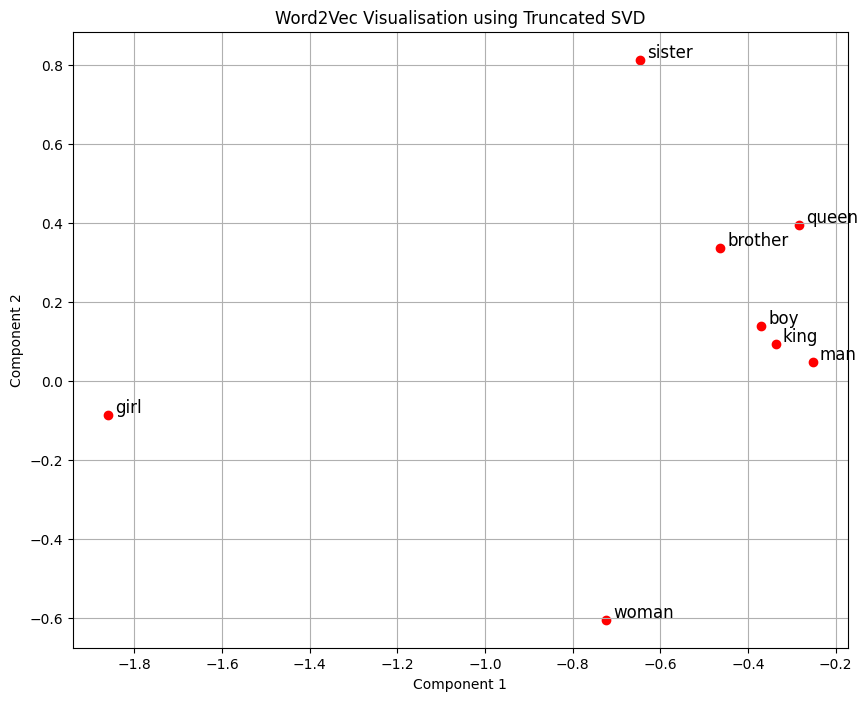

In [9]:
# Plot the following words or other words you are interested in
# You better pick those words that look different in the 2D space compared with the LSA vectors
words = ['sister', 'brother', 'woman', 'man', 'girl', 'boy', 'queen', 'king']

### YOUR CODE HERE ###
plt.figure(figsize=(10, 8))
for word in words:
    #检查单词是否在词表中
    if word in word2id:
        idx = word2id[word]
        #获取该词在 2D 空间中的坐标
        x, y = embeddings_2d[idx]
        
        #绘制点
        plt.scatter(x, y, color='red')
        #标注单词文本
        plt.annotate(word, (x, y), xytext=(5, 2), textcoords='offset points', fontsize=12)
    else:
        print(f"Warning: '{word}' is not in vocabulary.")
plt.title('Word2Vec Visualisation using Truncated SVD')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.grid(True)
plt.show()
### END YOUR CODE ###

## 6. (Set 2) Train with Different Hyperparameters

Run a second round of training with a different set of hyperparameters to compare performance.

Total vocabulary: 5328
Epoch [1/50], Step [1000], Loss: 2.4722
Epoch [1/50], Step [2000], Loss: 2.3282
Epoch [1/50], Step [3000], Loss: 2.4905


Epoch [1/50], Step [4000], Loss: 2.6429
Epoch [1/50], Step [5000], Loss: 3.2439
Epoch [1/50], Step [6000], Loss: 2.7753
Epoch [1/50], Step [7000], Loss: 2.8974
Epoch [1/50] 完成，平均 Loss: 2.7362
Epoch [2/50], Step [1000], Loss: 2.4225
Epoch [2/50], Step [2000], Loss: 2.2109
Epoch [2/50], Step [3000], Loss: 2.4429
Epoch [2/50], Step [4000], Loss: 2.6516
Epoch [2/50], Step [5000], Loss: 2.7431
Epoch [2/50], Step [6000], Loss: 2.6247
Epoch [2/50], Step [7000], Loss: 2.4767
Epoch [2/50] 完成，平均 Loss: 2.6096
Epoch [3/50], Step [1000], Loss: 2.3892
Epoch [3/50], Step [2000], Loss: 2.0813
Epoch [3/50], Step [3000], Loss: 2.3926
Epoch [3/50], Step [4000], Loss: 2.6308
Epoch [3/50], Step [5000], Loss: 2.6823
Epoch [3/50], Step [6000], Loss: 2.5466
Epoch [3/50], Step [7000], Loss: 2.4185
Epoch [3/50] 完成，平均 Loss: 2.5454
Epoch [4/50], Step [1000], Loss: 2.3441
Epoch [4/50], Step [2000], Loss: 2.0546
Epoch [4/50], Step [3000], Loss: 2.3675
Epoch [4/50], Step [4000], Loss: 2.6055
Epoch [4/50], Step [5000

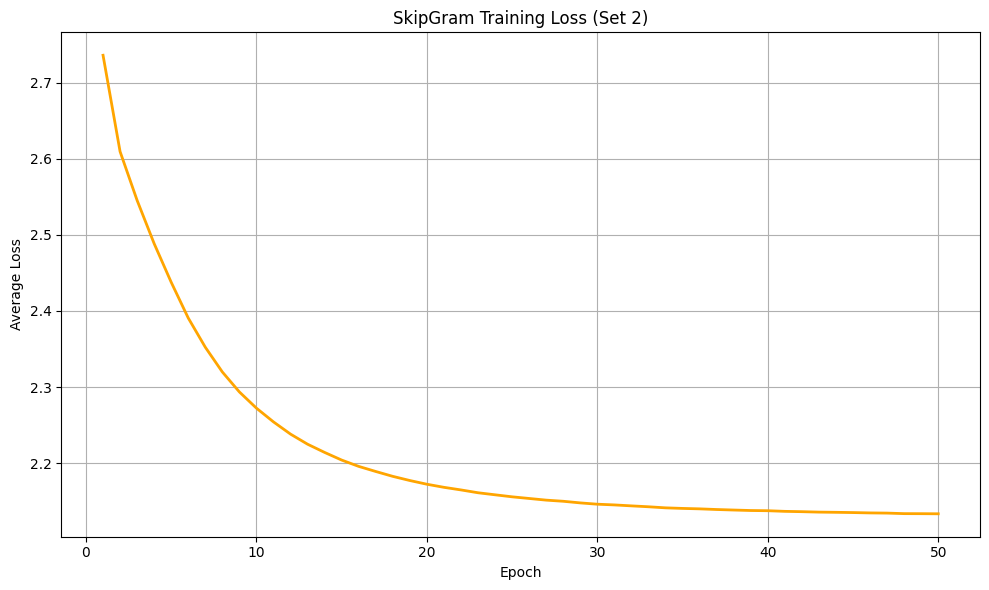

In [10]:
# --- Set 2 hyperparameters (tuned for stable convergence) ---
# Key changes vs Set 1:
#   - lower lr (0.002 vs 0.025): prevents loss explosion on larger batch/embedding
#   - smaller min_count (3 vs 5): keeps more words so more test analogies are evaluable
#   - fewer negative samples k=5: reduces gradient variance; too many k hurts on small corpus
initial_lr2  = 0.002
batch_size2  = 256
emb_size2    = 150
window_size2 = 5
k2           = 5
min_count2   = 3
epochs2      = 50

# Re-initialise corpus, model and optimizer
corpus2 = CorpusReader('shakespeare.txt', min_count=min_count2, lang='en')
model2  = SkipGram(corpus2.vocab_size, emb_size2)
opt2    = torch.optim.Adam(model2.parameters(), lr=initial_lr2)

data2    = generate_data(all_words, window_size2, k2, corpus2)
loader2  = batchify(data2, batch_size2)

loss2 = train(model2, loader2, opt2, epochs2)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(loss2) + 1), loss2, 'orange', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.title('SkipGram Training Loss (Set 2)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Save Set 2 embeddings
model2.save_embedding(corpus2.id2word, 'embeddings_set2.txt')

## 7. Word Analogy Evaluation

Evaluate both sets of embeddings on the word-analogy task (`questions-words-shakespeare.csv`).

In [11]:
from word_analogy import load_embeddings, evaluate_word_analogy, print_analogy_results

# --- Set 1 ---
wv1, _, _ = load_embeddings('embeddings.txt')
acc1, cor1, wrg1 = evaluate_word_analogy(wv1, 'questions-words-shakespeare.csv')
print_analogy_results(acc1, cor1, wrg1, 'Set 1 (emb=100, win=3, k=5)')

# --- Set 2 ---
wv2, _, _ = load_embeddings('embeddings_set2.txt')
acc2, cor2, wrg2 = evaluate_word_analogy(wv2, 'questions-words-shakespeare.csv')
print_analogy_results(acc2, cor2, wrg2, 'Set 2 (emb=150, win=5, k=10)')


Set 1 (emb=100, win=3, k=5) 词类比任务评估结果 (top-5)
总样本数: 928
正确预测: 7
错误预测: 921
准确率: 0.75%

部分正确样例:
  1. he : she = his : her (预测: her, top-5: [her, my, persuasion, That, My], 相似度: 0.5468)
  2. he : she = king : queen (预测: Katharina, top-5: [Katharina, patience, queen, daughter, mess], 相似度: 0.3950)
  3. he : she = son : daughter (预测: life, top-5: [life, daughter, father, sister, her], 相似度: 0.4844)
  4. he : she = brother : sister (预测: Clarence, top-5: [Clarence, patience, her, unfold, sister], 相似度: 0.3830)
  5. his : her = son : daughter (预测: daughter, top-5: [daughter, father, County, brother, life], 相似度: 0.4586)

部分错误样例:
  1. London : England = Paris : France (预测: called, 正确答案: France, top-5: [called, Death, success, conquest, youthful], 相似度: 0.4058)
  2. London : England = Rome : Italy (预测: lesser, 正确答案: Italy, top-5: [lesser, bears, Death, deed, greater], 相似度: 0.3653)
  3. Paris : France = Rome : Italy (预测: pick, 正确答案: Italy, top-5: [pick, prosper, foaming, shepherds, varlet], 相似度: 0.34